# Solved Notebook — ReExam 24th of August 2022

Course: **1MS041 Introduction to Data Science / Introduktion till dataanalys**  
This notebook includes the **full questions**, solved Python code, explanations, and printed outputs.

**Important note about data files:** Problems 4 and 5 require extra files/modules (`a_sequence.txt` and `exam_extras.py` / SMS data). They were not included with the uploaded PDF, so the notebook contains the complete solving code and will automatically run those parts once the files are placed in the same folder as the notebook.

In [1]:
# Common imports used in the notebook
import numpy as np
import math
import matplotlib.pyplot as plt
from pathlib import Path

np.random.seed(42)

## Problem 1 — Probability warmup

Let's say we have an exam question which consists of **50 yes/no questions**. From past performance of similar students, a randomly chosen student will know the correct answer to

\[
N \sim \mathrm{Binom}(50,0.8)
\]

questions. Furthermore, we assume that the student will guess the answer with equal probability to each question they don't know the answer to, i.e. given \(N\) we define

\[
Z \sim \mathrm{Binom}(50-N,1/2)
\]

as the number of correctly guessed answers. Define

\[
Y=N+Z
\]

so \(Y\) represents the number of total correct answers.

We are interested in setting a deterministic threshold \(T\), i.e. we would pass a student at threshold \(T\) if \(Y \geq T\). Here \(T\in\{0,1,2,\dots,50\}\).

1. **[3p]** Produce a simulation of 1000 students. Hint: Simulate \(N\) first then simulate \(Y \mid N\) and add the results. Numpy has `numpy.random.binomial` which you can simulate from.
2. **[3p]** For each threshold \(T\), produce a simulation as above and estimate the probability that the student knows less than 40 correct answers given that the student passed, i.e. \(N<40\). Put the answer in `problem1_probabilities` as a list.
3. **[2p]** What is the smallest value of \(T\) such that if \(Y\geq T\) then we are 90% certain that \(N\geq 40\)?

In [2]:
# Problem 1, Part 1
# Simulate N first: how many answers the student truly knows.
# Then simulate Z: how many of the unknown answers they guess correctly.
# Finally Y = N + Z.

n_students = 1000
N = np.random.binomial(n=50, p=0.8, size=n_students)
Z = np.array([np.random.binomial(n=50 - n, p=0.5) for n in N])
Y = N + Z

# Store the answer requested by the exam.
# Each row is one simulated student: [known_correct_N, guessed_correct_Z, total_correct_Y]
problem1_1000_samples = np.column_stack([N, Z, Y])

print("First 10 simulated students: columns are N, Z, Y")
print(problem1_1000_samples[:10])
print("\nAverage known correct N:", N.mean())
print("Average total correct Y:", Y.mean())

First 10 simulated students: columns are N, Z, Y
[[41  3 44]
 [35  8 43]
 [38  8 46]
 [39  7 46]
 [43  5 48]
 [43  4 47]
 [44  4 48]
 [37  8 45]
 [39  4 43]
 [39  5 44]]

Average known correct N: 40.089
Average total correct Y: 45.088


In [3]:
# Problem 1, Part 2
# For each threshold T, estimate P(N < 40 | Y >= T).
# To make the estimates more stable, we simulate many students once,
# then reuse the same simulation for all thresholds.

n_big = 200_000
N_big = np.random.binomial(n=50, p=0.8, size=n_big)
Z_big = np.array([np.random.binomial(n=50 - n, p=0.5) for n in N_big])
Y_big = N_big + Z_big

problem1_probabilities = []
for T in range(51):
    passed = (Y_big >= T)
    if passed.sum() == 0:
        prob = np.nan
    else:
        prob = np.mean(N_big[passed] < 40)
    problem1_probabilities.append(float(prob))

print("problem1_probabilities has length:", len(problem1_probabilities))
print("T : P(N < 40 | Y >= T)")
for T in range(35, 51):
    print(f"{T:2d}: {problem1_probabilities[T]:.4f}")

problem1_probabilities has length: 51
T : P(N < 40 | Y >= T)
35: 0.4172
36: 0.4172
37: 0.4171
38: 0.4167
39: 0.4155
40: 0.4118
41: 0.4028
42: 0.3832
43: 0.3474
44: 0.2955
45: 0.2326
46: 0.1671
47: 0.1098
48: 0.0665
49: 0.0380
50: 0.0104


In [4]:
# Problem 1, Part 3
# We need at least 90% certainty that N >= 40.
# That means P(N < 40 | Y >= T) <= 0.10.

problem1_T = next(T for T, p in enumerate(problem1_probabilities) if p <= 0.10)

print("Smallest T such that P(N >= 40 | Y >= T) >= 0.90:", problem1_T)
print("At this T, estimated P(N < 40 | Y >= T) =", problem1_probabilities[problem1_T])
print("At this T, estimated P(N >= 40 | Y >= T) =", 1 - problem1_probabilities[problem1_T])

Smallest T such that P(N >= 40 | Y >= T) >= 0.90: 48
At this T, estimated P(N < 40 | Y >= T) = 0.0664751559764801
At this T, estimated P(N >= 40 | Y >= T) = 0.9335248440235199


In [5]:
# Optional exact calculation check for Problem 1.
# This is not required by the question, but it confirms the simulation answer.

from math import comb

pN = np.array([comb(50, n) * (0.8 ** n) * (0.2 ** (50 - n)) for n in range(51)])
exact_bad_probs = []

for T in range(51):
    numerator = 0.0
    denominator = 0.0
    for n in range(51):
        # P(Y >= T | N=n) = P(Z >= T-n), where Z ~ Binom(50-n, 1/2)
        k_min = max(0, T - n)
        if k_min <= 50 - n:
            p_pass_given_n = sum(comb(50 - n, z) * (0.5 ** (50 - n)) for z in range(k_min, 50 - n + 1))
        else:
            p_pass_given_n = 0.0
        denominator += pN[n] * p_pass_given_n
        if n < 40:
            numerator += pN[n] * p_pass_given_n
    exact_bad_probs.append(numerator / denominator if denominator > 0 else np.nan)

exact_T = next(T for T, p in enumerate(exact_bad_probs) if p <= 0.10)
print("Exact smallest T:", exact_T)
print("Exact P(N < 40 | Y >= T):", exact_bad_probs[exact_T])
print("Exact P(N >= 40 | Y >= T):", 1 - exact_bad_probs[exact_T])

Exact smallest T: 48
Exact P(N < 40 | Y >= T): 0.06692877062661873
Exact P(N >= 40 | Y >= T): 0.9330712293733813


### Problem 1 final answer

- `problem1_1000_samples` contains the 1000 simulated students.
- `problem1_probabilities` contains the estimated probabilities for thresholds \(T=0,1,\dots,50\).
- The smallest threshold is:

\[
\boxed{T=48}
\]

## Problem 2 — Inversion sampling

In many areas of data science and machine learning we need to produce random samples in different ways. This can be done to compute difficult integrals or validate algorithms.

1. **[2p]** Produce 1000 samples from the distribution below using inversion sampling

\[
F(x)=
\begin{cases}
0, & x\leq 0\\
\sin(x), & 0<x<\pi/2\\
1, & x\geq \pi/2
\end{cases}
\]

and show your result with a histogram. Also what is the true density? Provide a plot of the true density between \(0\) and \(\pi/2\).

2. **[3p]** Consider a random variable \(X\sim F\). Your goal is to estimate \(E[X]\). Do this by producing 1000 different experiments, each sampling 1000 samples from \(X\), and compute the empirical mean. Provide the 0.025 and the 0.975 quantile of the experiments.

3. **[3p]** Use Hoeffding's inequality to produce a 95% confidence interval for the estimated mean above.

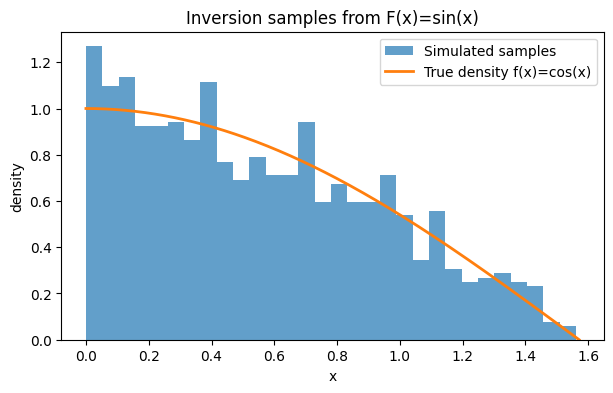

First 10 samples:
[8.14705931e-01 6.47001104e-01 7.80087791e-04 7.23737061e-01
 1.14426651e+00 1.00725474e-01 9.04397416e-01 2.98584064e-01
 1.15728898e-01 7.95304558e-01]
True density: f(x) = cos(x), for 0 < x < pi/2


In [6]:
# Problem 2, Part 1
# Inversion sampling:
# If U ~ Uniform(0,1), then set F(X)=U.
# Since F(x)=sin(x), we get X = arcsin(U).

U = np.random.uniform(0, 1, 1000)
samples = np.arcsin(U)

# True density is derivative of F(x): f(x)=cos(x), for 0 < x < pi/2.
x_grid = np.linspace(0, np.pi/2, 300)
true_density = np.cos(x_grid)

plt.figure(figsize=(7, 4))
plt.hist(samples, bins=30, density=True, alpha=0.7, label="Simulated samples")
plt.plot(x_grid, true_density, linewidth=2, label="True density f(x)=cos(x)")
plt.xlabel("x")
plt.ylabel("density")
plt.title("Inversion samples from F(x)=sin(x)")
plt.legend()
plt.show()

print("First 10 samples:")
print(samples[:10])
print("True density: f(x) = cos(x), for 0 < x < pi/2")

In [7]:
# Problem 2, Part 2
# Produce 1000 experiments.
# In each experiment, draw 1000 samples from F and compute the mean.

n_experiments = 1000
samples_per_experiment = 1000

means = []
for _ in range(n_experiments):
    U_exp = np.random.uniform(0, 1, samples_per_experiment)
    X_exp = np.arcsin(U_exp)
    means.append(float(np.mean(X_exp)))

quantile_0025 = float(np.quantile(means, 0.025))
quantile_0975 = float(np.quantile(means, 0.975))

print("Length of means:", len(means))
print("Estimated E[X] from all experiment means:", np.mean(means))
print("0.025 quantile:", quantile_0025)
print("0.975 quantile:", quantile_0975)

# True mean, for checking:
# E[X] = integral from 0 to pi/2 of x*cos(x) dx = pi/2 - 1.
true_mean = np.pi/2 - 1
print("True E[X] = pi/2 - 1 =", true_mean)

Length of means: 1000
Estimated E[X] from all experiment means: 0.5708444760487532
0.025 quantile: 0.5466899444079529
0.975 quantile: 0.5924285850055466
True E[X] = pi/2 - 1 = 0.5707963267948966


In [8]:
# Problem 2, Part 3
# Hoeffding inequality for bounded variables X in [a,b]:
# P(|sample_mean - E[X]| >= epsilon) <= 2 exp(-2 n epsilon^2 / (b-a)^2)
# For 95% confidence, delta=0.05.
# So epsilon = (b-a)*sqrt(log(2/delta)/(2n)).

sample_mean = float(np.mean(samples))
a = 0
b = np.pi/2
n = len(samples)
delta = 0.05

epsilon = (b - a) * np.sqrt(np.log(2/delta) / (2*n))
l_edge = sample_mean - epsilon
r_edge = sample_mean + epsilon

print("Sample mean from the first 1000 samples:", sample_mean)
print("Hoeffding epsilon:", epsilon)
print("Confidence interval around the mean is [%.4f, %.4f]" % (l_edge, r_edge))

Sample mean from the first 1000 samples: 0.5642996136894981
Hoeffding epsilon: 0.06746089691018328
Confidence interval around the mean is [0.4968, 0.6318]


### Problem 2 final answer

- Inversion sampling uses \(X=\arcsin(U)\), where \(U\sim \mathrm{Uniform}(0,1)\).
- The true density is:

\[
f(x)=\cos(x), \quad 0<x<\pi/2
\]

- The true mean is:

\[
E[X]=\int_0^{\pi/2}x\cos(x)dx=\frac{\pi}{2}-1\approx 0.5708
\]

## Problem 3 — Concentration of measure

As you recall, we said that concentration of measure was simply the phenomenon where we expect that the probability of a large deviation of some quantity becomes smaller as we observe more samples.

1. Which of the following will **exponentially concentrate**, i.e. for some \(C_1,C_2,C_3,C_4\),

\[
P(Z-E[Z]\geq \epsilon) \leq C_1 e^{-C_2n\epsilon^2}\wedge C_3e^{-C_4n(\epsilon+1)}
\]

Alternatives:

1. The empirical mean of i.i.d. sub-Gaussian random variables.
2. The empirical mean of i.i.d. sub-Exponential random variables.
3. The empirical mean of i.i.d. bounded random variables.
4. The empirical variance of i.i.d. bounded random variables.
5. The empirical mean of i.i.d. random variables with finite variance.
6. The empirical variance of i.i.d. random variables with finite variance.
7. The empirical variance of i.i.d. sub-Gaussian random variables.
8. The empirical third moment of i.i.d. bounded random variables.
9. The empirical fourth moment of i.i.d. sub-Gaussian random variables.
10. The empirical mean of i.i.d. deterministic random variables.
11. The empirical tenth moment of i.i.d. Bernoulli random variables.

2. Which of the above will concentrate in the weaker sense, that for some \(C_1\),

\[
P(Z-E[Z]\geq \epsilon) \leq \frac{C_1}{n\epsilon^2}?
\]

In [9]:
# Problem 3 answers

# Exponential concentration:
# 1 yes: sub-Gaussian means concentrate exponentially.
# 2 yes: sub-exponential means concentrate with Bernstein-type exponential tails.
# 3 yes: bounded means concentrate by Hoeffding.
# 4 yes: if X is bounded, X^2 is bounded, so empirical variance concentrates.
# 5 no: finite variance only gives Chebyshev-type concentration, not exponential.
# 6 no: finite variance alone is not enough for sample variance concentration at this rate.
# 7 yes: if X is sub-Gaussian, X^2 is sub-exponential, so variance concentrates.
# 8 yes: bounded X means X^3 is bounded.
# 9 no: sub-Gaussian X has finite moments, but X^4 is not generally sub-exponential with this Bernstein form.
# 10 yes: deterministic variables have zero deviation.
# 11 yes: Bernoulli variables are bounded, so the tenth moment is bounded.

problem3_answer_1 = [1, 2, 3, 4, 7, 8, 10, 11]

# Weak concentration:
# Chebyshev-type bounds require finite variance of the averaged quantity.
# All exponentially concentrating cases also weakly concentrate.
# Alternative 5 also weakly concentrates by Chebyshev.
# Alternative 9 weakly concentrates because sub-Gaussian variables have finite eighth moment,
# so the empirical fourth moment has finite variance.
# Alternative 6 is excluded because finite variance of X alone does not guarantee finite variance of X^2.

problem3_answer_2 = [1, 2, 3, 4, 5, 7, 8, 9, 10, 11]

print("problem3_answer_1 =", problem3_answer_1)
print("problem3_answer_2 =", problem3_answer_2)

problem3_answer_1 = [1, 2, 3, 4, 7, 8, 10, 11]
problem3_answer_2 = [1, 2, 3, 4, 5, 7, 8, 9, 10, 11]


### Problem 3 final answer

\[
\boxed{\text{Exponential: }[1,2,3,4,7,8,10,11]}
\]

\[
\boxed{\text{Weak: }[1,2,3,4,5,7,8,9,10,11]}
\]

## Problem 4 — Markov chain from `a_sequence.txt`

In this problem you will be working with a text file `a_sequence.txt`, found in the data folder. This contains a sequence of numbers that are observations of a Markov chain. The goal of this exercise is to analyze this sequence in different ways.

1. **[2p]** Take the file `a_sequence.txt` and load it as a list of integers. Use bash or something to figure out how to parse the file.
2. **[2p]** Define a Markov chain from this list of integers:
   1. What are the states?
   2. How many states are there?
3. **[2p]** Estimate the transition probability of going from state 42 to state 16.
4. **[2p]** Find the transition matrix \(P\) and compute the matrix power \(P^{10}v\) where \(v=(1,0,\dots,0)\).

In [10]:
# Problem 4, Part 1
# This cell loads a_sequence.txt if it is available.
# Put a_sequence.txt either in the same folder as this notebook or inside a folder called data/.

possible_paths = [Path("a_sequence.txt"), Path("data/a_sequence.txt"), Path("/mnt/data/a_sequence.txt")]
sequence_path = next((p for p in possible_paths if p.exists()), None)

if sequence_path is None:
    numbers = None
    print("a_sequence.txt was not included with the uploaded PDF, so Problem 4 cannot produce numeric outputs yet.")
    print("Place a_sequence.txt in the same folder as this notebook, then rerun Problem 4 cells.")
else:
    raw_text = sequence_path.read_text()
    # Robust parsing: replace commas/newlines/tabs by spaces, then convert tokens to integers.
    cleaned = raw_text.replace(",", " ").replace("\n", " ").replace("\t", " ")
    numbers = [int(tok) for tok in cleaned.split()]
    print("Loaded", len(numbers), "numbers from", sequence_path)
    print("First 20 numbers:", numbers[:20])

a_sequence.txt was not included with the uploaded PDF, so Problem 4 cannot produce numeric outputs yet.
Place a_sequence.txt in the same folder as this notebook, then rerun Problem 4 cells.


### Problem 4 explanation

The **states** of the Markov chain are the unique values appearing in the sequence.  
A **transition** means moving from one observed number to the next observed number in the list.

For example, if part of the sequence is:

\[
42,16,8,42
\]

then we observe transitions \(42\to16\), \(16\to8\), and \(8\to42\).

The transition probability \(P(i\to j)\) is estimated by:

\[
\widehat{P}(i\to j)=\frac{\text{number of transitions from }i\text{ to }j}{\text{number of transitions out of }i}
\]

In the code below, the transition matrix is stored with **columns summing to 1**, because the exam says to compute \(P^{10}v\) using a column vector \(v\).

In [11]:
# Problem 4, Parts 2-4

if numbers is None:
    n_states = None
    states = None
    transition_probability = None
    P = None
    steady_state_v = None
    print("Skipped because a_sequence.txt is missing.")
else:
    states = sorted(set(numbers))
    n_states = len(states)
    state_to_index = {state: i for i, state in enumerate(states)}
    
    print("States:", states)
    print("Number of states:", n_states)
    
    # Count transitions. counts[to_index, from_index] stores count of from_state -> to_state.
    counts = np.zeros((n_states, n_states), dtype=float)
    for current_state, next_state in zip(numbers[:-1], numbers[1:]):
        from_idx = state_to_index[current_state]
        to_idx = state_to_index[next_state]
        counts[to_idx, from_idx] += 1
    
    # Estimate P(42 -> 16)
    if 42 in state_to_index and 16 in state_to_index:
        from_42 = state_to_index[42]
        to_16 = state_to_index[16]
        total_out_of_42 = counts[:, from_42].sum()
        transition_probability = counts[to_16, from_42] / total_out_of_42 if total_out_of_42 > 0 else np.nan
    else:
        transition_probability = np.nan
    
    print("Estimated transition probability P(42 -> 16):", transition_probability)
    
    # Build transition matrix P with columns summing to 1.
    P = np.zeros_like(counts)
    col_sums = counts.sum(axis=0)
    for j in range(n_states):
        if col_sums[j] > 0:
            P[:, j] = counts[:, j] / col_sums[j]
        else:
            # If a state has no outgoing transitions, keep it at itself.
            P[j, j] = 1.0
    
    print("Column sums of P, should be 1:")
    print(P.sum(axis=0))
    
    v = np.zeros(n_states)
    v[0] = 1
    steady_state_v = np.linalg.matrix_power(P, 10) @ v
    
    print("P^10 v:")
    print(steady_state_v)

Skipped because a_sequence.txt is missing.


## Problem 5 — SMS spam filtering

In the following problem we will explore SMS spam texts. The dataset is the SMS Spam Collection Dataset and the exam provides a way to load the data. If you run the appropriate cell below, the result will be in the `spam_no_spam` variable. The result is a list of tuples with the first position in the tuple being the SMS text and the second being a flag: `0 = not spam` and `1 = spam`.

1. **[3p]** Let \(X\) be the random variable that represents each SMS text, and let \(Y\) represent whether text is spam or not, i.e. \(Y\in\{0,1\}\). Estimate:

\[
P(Y=1 \mid \text{"free" or "prize" is in }X)
\]

That is, the probability that the SMS is spam given that “free” or “prize” occurs in the SMS. This is **precision**.

2. **[3p]** Estimate the probability that the word “free” or “prize” is in the text given that it is spam. This is **recall**:

\[
P(\text{"free" or "prize" is in }X \mid Y=1)
\]

3. **[2p]** Provide a “90%” interval of confidence around the true probability from part 1. Use the Hoeffding inequality to obtain, for your estimate \(\hat P\), an \(l>0\) such that:

\[
P(\hat P-l \leq E[\hat P] \leq \hat P+l) \geq 0.9
\]

In [12]:
# Problem 5 data loading
# This tries the exam's loader first.
# If exam_extras.py is missing, it also tries to load a local SMSSpamCollection-type file if available.

spam_no_spam = None

try:
    from exam_extras import load_sms
    spam_no_spam = load_sms()
    print("Loaded SMS data using exam_extras.load_sms().")
except Exception as e:
    print("Could not load using exam_extras.load_sms():", repr(e))
    print("Trying local SMS data files...")
    
    possible_sms_paths = [
        Path("SMSSpamCollection"),
        Path("SMSSpamCollection.txt"),
        Path("spam.csv"),
        Path("data/SMSSpamCollection"),
        Path("data/SMSSpamCollection.txt"),
        Path("data/spam.csv"),
        Path("/mnt/data/SMSSpamCollection"),
        Path("/mnt/data/SMSSpamCollection.txt"),
        Path("/mnt/data/spam.csv"),
    ]
    sms_path = next((p for p in possible_sms_paths if p.exists()), None)
    
    if sms_path is not None:
        rows = []
        for line in sms_path.read_text(encoding="utf-8", errors="ignore").splitlines():
            if not line.strip():
                continue
            # Common format: label<TAB>message, where label is ham/spam.
            if "\t" in line:
                label, text = line.split("\t", 1)
            elif "," in line:
                label, text = line.split(",", 1)
            else:
                continue
            label = label.strip().lower().replace('"', '')
            if label in ["ham", "0"]:
                y = 0
            elif label in ["spam", "1"]:
                y = 1
            else:
                continue
            rows.append((text.strip(), y))
        spam_no_spam = rows
        print("Loaded", len(spam_no_spam), "SMS rows from", sms_path)
    else:
        print("SMS data was not included with the uploaded PDF, so Problem 5 cannot produce numeric outputs yet.")
        print("Place exam_extras.py and its data, or SMSSpamCollection, in the same folder and rerun.")

if spam_no_spam is not None:
    print("First 3 rows:")
    for row in spam_no_spam[:3]:
        print(row)

Could not load using exam_extras.load_sms(): ModuleNotFoundError("No module named 'exam_extras'")
Trying local SMS data files...
SMS data was not included with the uploaded PDF, so Problem 5 cannot produce numeric outputs yet.
Place exam_extras.py and its data, or SMSSpamCollection, in the same folder and rerun.


In [13]:
# Problem 5 solution code

if spam_no_spam is None:
    problem5_hatP = None
    problem5_hatP2 = None
    problem5_l = None
    print("Skipped because SMS data is missing.")
else:
    def contains_free_or_prize(text):
        text_lower = text.lower()
        return ("free" in text_lower) or ("prize" in text_lower)
    
    # Convert to clean arrays/lists.
    texts = [row[0] for row in spam_no_spam]
    labels = np.array([int(row[1]) for row in spam_no_spam])
    has_keyword = np.array([contains_free_or_prize(text) for text in texts])
    
    # Part 1: precision = P(Y=1 | keyword present)
    keyword_count = has_keyword.sum()
    spam_and_keyword_count = ((labels == 1) & has_keyword).sum()
    problem5_hatP = spam_and_keyword_count / keyword_count if keyword_count > 0 else np.nan
    
    # Part 2: recall = P(keyword present | Y=1)
    spam_count = (labels == 1).sum()
    problem5_hatP2 = spam_and_keyword_count / spam_count if spam_count > 0 else np.nan
    
    # Part 3: Hoeffding 90% interval around Part 1.
    # For Bernoulli samples, P(|hatP - P| >= l) <= 2 exp(-2*n*l^2)
    # Set delta = 0.10, so l = sqrt(log(2/delta)/(2n)).
    delta = 0.10
    n = keyword_count
    problem5_l = np.sqrt(np.log(2/delta)/(2*n)) if n > 0 else np.nan
    
    print("Number of SMS messages:", len(spam_no_spam))
    print("Number containing 'free' or 'prize':", keyword_count)
    print("Number spam and containing keyword:", spam_and_keyword_count)
    print("Number spam:", spam_count)
    print("problem5_hatP  = P(spam | keyword) =", problem5_hatP)
    print("problem5_hatP2 = P(keyword | spam) =", problem5_hatP2)
    print("problem5_l for 90% Hoeffding interval =", problem5_l)
    print("90% Hoeffding interval for Part 1:", (problem5_hatP - problem5_l, problem5_hatP + problem5_l))

Skipped because SMS data is missing.


### Problem 5 final answer format

When the SMS dataset is available, the notebook fills:

```python
problem5_hatP   # precision = P(spam | "free" or "prize")
problem5_hatP2  # recall    = P("free" or "prize" | spam)
problem5_l      # Hoeffding radius for a 90% confidence interval
```

The 90% interval is:

\[
[\hat P-l,\hat P+l]
\]